# Titanic Machine Learning Case Study

This notebook is structured to guide you through the key phases of a Machine Learning project:

- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Training and Evaluation

Use the Titanic dataset from Kaggle: https://www.kaggle.com/c/titanic/data


# Imports

In [1]:
# imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV

# 1. Exploratory Data Analysis (EDA)
Os datasets foram importados para realizar uma análise inicial, permitindo avaliar a qualidade dos dados, entender sua estrutura e identificar ajustes necessários.


In [2]:
# Load the dataset and display the first few rows
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

train.head()
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
# Display geral informations and descriptive statistics
train.info()

print("\nDescriptive statistics:")
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Descriptive statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# Verifying for missing values
print("\nMissing values:")
train.isnull().sum()


Missing values:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### 1.1 Histogramas
Histogramas gerados para visualizar a distribuição das variáveis, com destaque para a mediana, facilitando a identificação de padrões, tendências e a compreensão da dispersão e dos valores típicos dos dados.

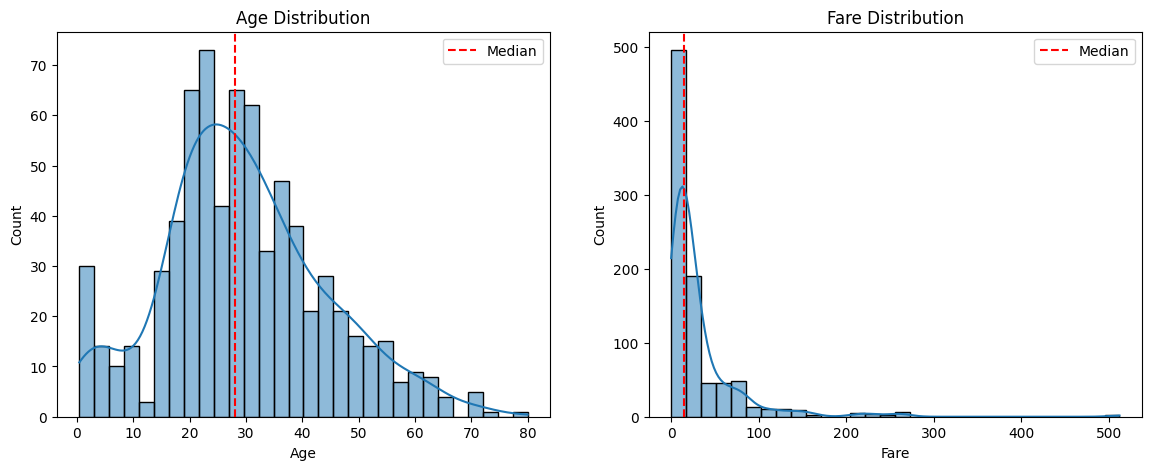

In [5]:
# Histograms for 'age' and 'fare'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    train['Age'].dropna(), bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')
# Highlighting the median
axes[0].axvline(train['Age'].median(), color='red', linestyle='--', label='Median')
axes[0].legend() 

sns.histplot(train['Fare'].dropna(), bins=30, kde=True, ax=axes[1])
axes[1].set_title('Fare Distribution') 
# Highlighting the median
axes[1].axvline(train['Fare'].median(), color='red', linestyle='--', label='Median')
axes[1].legend()

plt.show()

### 1.2 Gráficos de barras
Gráficos de barras foram gerados para analisar a relação da sobrevivência com diferentes categorias, permitindo identificar padrões e possíveis influências de variáveis categóricas. A inclusão de rótulos nas barras facilita a interpretação dos dados.

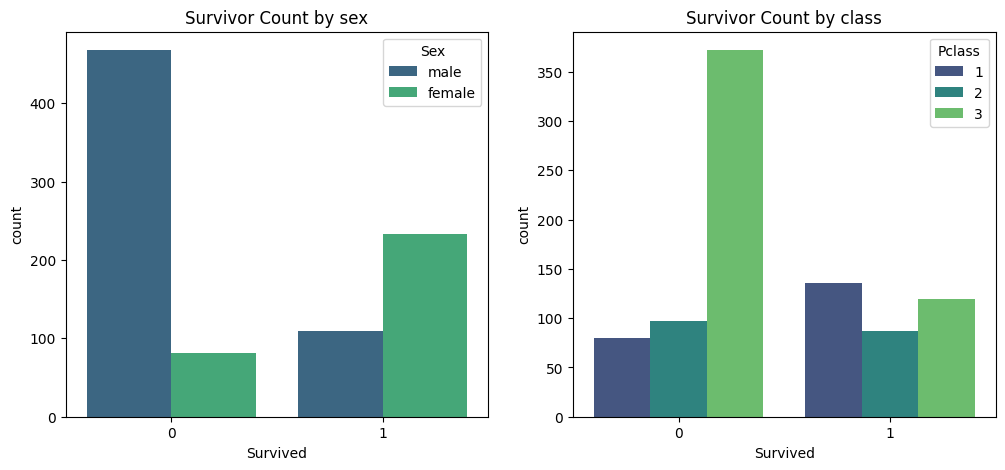

In [6]:
# Survivor count by 'sex' and 'class'
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

viridis_palette_sex = sns.color_palette("viridis", as_cmap=False, n_colors=len(train['Sex'].unique()))
sns.countplot(x="Survived", hue="Sex", data=train, ax=axes[0], palette=viridis_palette_sex)
axes[0].set_title("Survivor Count by sex")

viridis_palette_pclass = sns.color_palette("viridis", as_cmap=False, n_colors=len(train['Pclass'].unique()))
sns.countplot(x="Survived", hue="Pclass", data=train, ax=axes[1], palette=viridis_palette_pclass)
axes[1].set_title("Survivor Count by class")
plt.show()


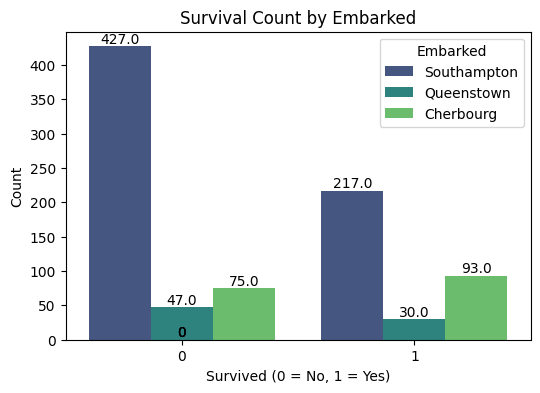

In [7]:
# Survivors by port of embarkation
city_map = {'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'}
train['Embarked'] = train['Embarked'].map(city_map)

plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', hue='Embarked', data=train, palette='viridis')

plt.title('Survival Count by Embarked')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Add rotules to the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), 
                       ha='center', va='bottom', fontsize=10, color='black')

plt.show()


### 1.3 Boxplots
Boxplots foram gerados para analisar a relação entre variáveis numéricas. Essas visualizações permitem identificar padrões, outliers e possíveis influências dessas fatores nas chances de sobrevivência.

C:\Users\cadl\AppData\Local\Temp\ipykernel_20116\3006969717.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Age', data=train, palette='viridis')
C:\Users\cadl\AppData\Local\Temp\ipykernel_20116\3006969717.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=train, palette='viridis')


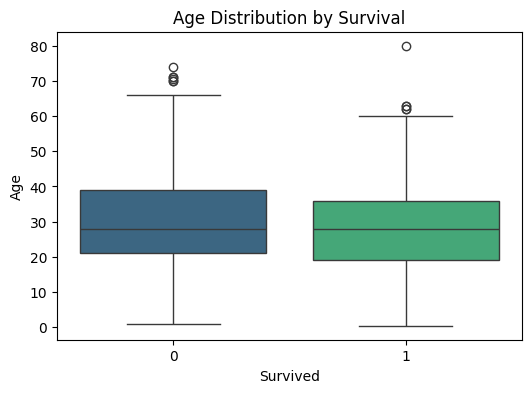

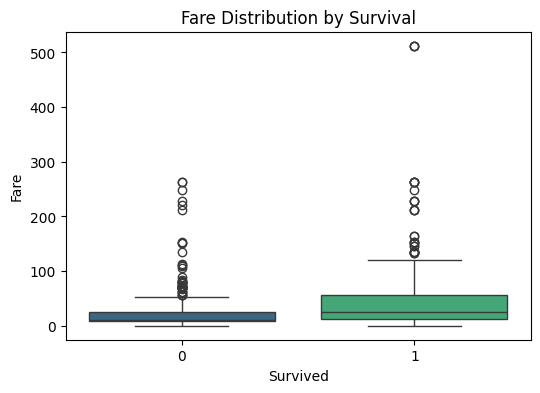

In [8]:
# Age vs Survival
plt.figure(figsize=(6, 4))
sns.boxplot(x='Survived', y='Age', data=train, palette='viridis')
plt.title('Age Distribution by Survival')

# Fare vs Survival
plt.figure(figsize=(6, 4))
sns.boxplot(x='Survived', y='Fare', data=train, palette='viridis')
plt.title('Fare Distribution by Survival')
plt.show()

# 2 - Feature Engineering
Transformação dos dados brutos em informações mais estruturadas, permitindo que o modelo identifique melhor os padrões presentes, melhore a qualidade dos dados, aumente o desempenho e extraia o máximo valor das variáveis.

### 2.1 Criação de variáveis familiares e extração de títulos
Criação de variáveis que representam o tamanho da família a bordo e se o passageiro está sozinho, além da extração e agrupamento de títulos dos nomes.

In [9]:
# Create a family variable on board
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
train['IsAlone'] = (train['FamilySize'] == 1).astype(int)
display(train[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head())

# Title extraction
print("\nExtracting titles from names...")
train['Title'] = train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
train['Title'] = train['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 
                                         'Sir', 'Jonkheer', 'Dona'], 'Rare')
train['Title'] = train['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
title_map = {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4}
train['Title'] = train['Title'].map(title_map).fillna(4)
display(train[['Name', 'Title']].head())

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1



Extracting titles from names...


,Name,Title
0,"Braund, Mr. Owen Harris",0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2
2,"Heikkinen, Miss. Laina",1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",2
4,"Allen, Mr. William Henry",0


### 2.2 Discretização das variáveis
As variáveis contínuas de tarifa e idade foram discretizadas em faixas (bins) para facilitar a análise de padrões e a modelagem, permitindo que o algoritmo capture relações não lineares e agrupamentos relevantes.

In [10]:
# Binning 'Fare' and 'Age'
train['FareBin'] = pd.qcut(train['Fare'], 4, labels=False)
train['AgeBin'] = pd.cut(train['Age'], bins=[0, 12, 18, 35, 60, 80], labels=False)
display(train[['Age', 'AgeBin', 'Fare', 'FareBin']].head())

,Age,AgeBin,Fare,FareBin
0,22.0,2.0,7.2500,0
1,38.0,3.0,71.2833,3
2,26.0,2.0,7.9250,1
3,35.0,2.0,53.1000,3
4,35.0,2.0,8.0500,1


### 2.3 Tratamento de valores ausentes e padronização
Preenchimento de dados faltantes, transformação de variáveis categóricas em numéricas e padronização das variáveis numéricas para garantir dados completos e em escala adequada, facilitando o aprendizado do modelo.

In [11]:
# Handling missing values
train['Age'].fillna(train['Age'].median(), inplace=True)
train['Fare'].fillna(train['Fare'].median(), inplace=True)

# Transform categorical variables into numerical ones
train["Sex"] = train["Sex"].map({"male": 0, "female": 1})

# Padronize of numerical variables
scaler = StandardScaler()
num_features = ['Age', 'Fare', 'FamilySize']
train[num_features] = scaler.fit_transform(train[num_features])

train.head()


C:\Users\cadl\AppData\Local\Temp\ipykernel_20116\1357346687.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].median(), inplace=True)
C:\Users\cadl\AppData\Local\Temp\ipykernel_20116\1357346687.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Title,FareBin,AgeBin
0,1,0,3,"Braund, Mr. Owen Harris",0,-0.565736,1,0,A/5 21171,-0.502445,NaN,Southampton,0.059160,0,0,0,2.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.663861,1,0,PC 17599,0.786845,C85,Cherbourg,0.059160,0,2,3,3.0
2,3,1,3,"Heikkinen, Miss. Laina",1,-0.258337,0,0,STON/O2. 3101282,-0.488854,NaN,Southampton,-0.560975,1,1,1,2.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.433312,1,0,113803,0.420730,C123,Southampton,0.059160,0,2,3,2.0
4,5,0,3,"Allen, Mr. William Henry",0,0.433312,0,0,373450,-0.486337,NaN,Southampton,-0.560975,1,0,1,2.0


# 3 - Model training and evaluation
Nesta etapa, o modelo é treinado com os dados preparados e avaliado utilizando métricas adequadas para medir seu desempenho e capacidade de generalização.

### 3.1 Preparação dos dados para treinamento
Separação das variáveis preditoras (X) e alvo (y), divisão dos dados em conjuntos de treino e validação com estratificação, e tratamento de dados para garantir que apenas variáveis numéricas e sem valores ausentes sejam utilizadas no treinamento do modelo.

In [12]:
# Separation of X and Y
X = train.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, errors='ignore')
y = train['Survived']

# Split training/validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Remove non-numeric columns
X_train = X_train.select_dtypes(include=[np.number])
X_val = X_val.select_dtypes(include=[np.number])

# Impute missing values in X_train and X_val
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_imputed = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns, index=X_val.index)


### 3.2 Treinamento e avaliação dos modelos 
Os modelos de Regressão Logística e Random Forest foram treinados com os dados preparados e avaliados usando métricas como acurácia, F1 Score, matriz de confusão e relatório de classificação, para comparar seu desempenho na predição da sobrevivência.

In [13]:
# Model training
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_imputed, y_train)
y_pred_logreg = logreg.predict(X_val_imputed)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_imputed, y_train)
y_pred_rf = rf.predict(X_val_imputed)

print("Logistic Regression:")
print("Acurácia:", accuracy_score(y_val, y_pred_logreg))
print("F1 Score:", f1_score(y_val, y_pred_logreg))
print("Matriz de Confusão:\n", confusion_matrix(y_val, y_pred_logreg))
print(classification_report(y_val, y_pred_logreg))

print("\nRandom Forest:")
print("Acurácia:", accuracy_score(y_val, y_pred_rf))
print("F1 Score:", f1_score(y_val, y_pred_rf))
print("Matriz de Confusão:\n", confusion_matrix(y_val, y_pred_rf))
print(classification_report(y_val, y_pred_rf))

Logistic Regression:
Acurácia: 0.8156424581005587
F1 Score: 0.7480916030534351
Matriz de Confusão:
 [[97 13]
 [20 49]]
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179


Random Forest:
Acurácia: 0.8156424581005587
F1 Score: 0.7591240875912408
Matriz de Confusão:
 [[94 16]
 [17 52]]
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.76      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



### 3.4 Matriz de confusão
As matrizes de confusão dos modelos de Regressão Logística e Random Forest foram visualizadas para facilitar a interpretação dos resultados, evidenciando acertos e erros nas previsões de sobrevivência.

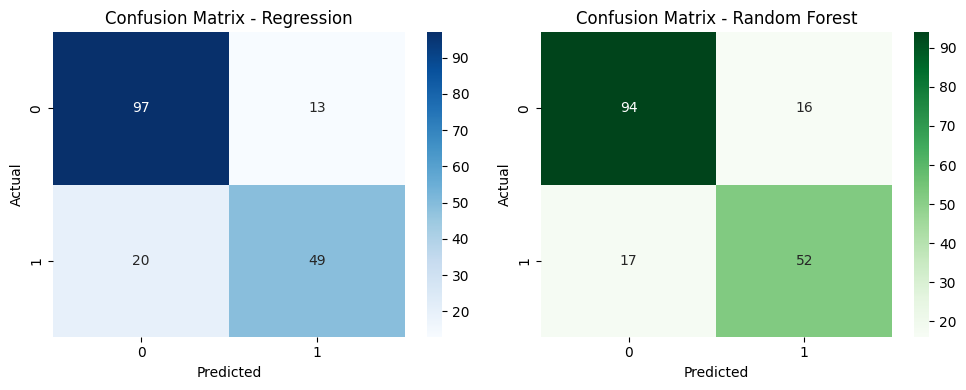

In [14]:
# Confusion matrix visualization
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_val, y_pred_logreg), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_val, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

### 3.4 Feature importance
As importâncias das variáveis foram recalculadas e visualizadas para mostrar quais atributos tiveram maior impacto nas decisões do modelo Random Forest, auxiliando na interpretação e possível refinamento do modelo.

C:\Users\cadl\AppData\Local\Temp\ipykernel_20116\1826806636.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


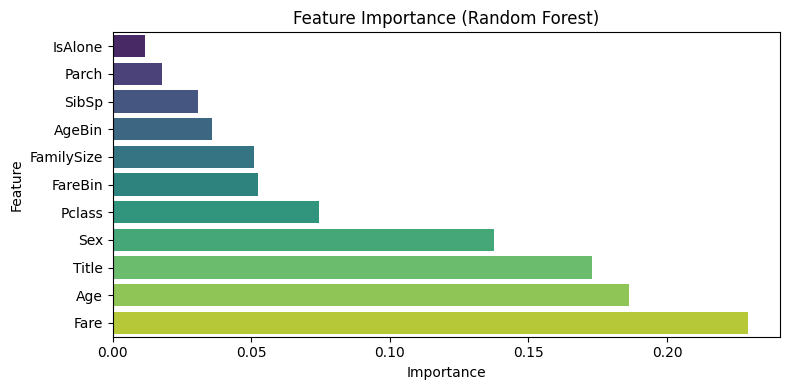

In [15]:
# Recalculate feature importances
importances = rf.feature_importances_
features = X_train_imputed.columns
sorted_idx = np.argsort(importances)

plt.figure(figsize=(8, 4))
sns.barplot(
    x=importances[sorted_idx],
    y=np.array(features)[sorted_idx],
    palette='viridis'
)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 3.5 Grid search
Foi realizada uma busca em grade (Grid Search) para ajustar os principais hiperparâmetros da Regressão Logística e do Random Forest, visando maximizar a acurácia por meio de validação cruzada.

In [16]:
# Define parameters for Logistic Regression
param_grid_logreg = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
}

# GridSearch for Logistic Regression
grid_logreg = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_logreg, cv=5, scoring='accuracy')
grid_logreg.fit(X_train_imputed, y_train)
print("Best parameters (Logistic Regression):", grid_logreg.best_params_)
print("Best accuracy:", grid_logreg.best_score_)

# Define parameters for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
}

# GridSearch for Random Forest
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train_imputed, y_train)
print("\nBest parameters (Random Forest):", grid_rf.best_params_)
print("Best accuracy:", grid_rf.best_score_)


Best parameters (Logistic Regression): {'C': 1, 'solver': 'liblinear'}
Best accuracy: 0.8062444597655866

Best parameters (Random Forest): {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 50}
Best accuracy: 0.8343346794051019


# 4. Conclusão
Com base nos dados e no resultado dos modelos, é possível concluir que: 
- Mulheres tinham uma chance significativamente maior de sobreviver. O sexo foi uma das variáveis mais importantes para a predição, refletindo a política de "mulheres e crianças primeiro" nos botes salva-vidas.
- Crianças (idades mais baixas, especialmente no grupo 'AgeBin' mais baixo) também apresentaram maior taxa de sobrevivência, reforçando a prioridade dada a elas durante o resgate.
- Passageiros da 1ª classe (Pclass = 1) tiveram maior chance de sobreviver, enquanto os da 3ª classe tiveram as menores chances. Isso mostra o impacto do status socioeconômico no acesso aos botes.
- Passageiros que embarcaram em Cherbourg (C) tiveram uma taxa de sobrevivência maior do que os que embarcaram em Southampton (S) ou Queenstown (Q).
- Pessoas acompanhadas (FamilySize > 1) ou com títulos de respeito (como Mrs, Miss) também tiveram mais chances, enquanto quem estava sozinho (IsAlone = 1) teve menos chance de sobreviver.

Quem tinha menor chance de sobreviver:
- Homens adultos.
- Passageiros da 3ª classe.
- Pessoas viajando sozinhas.
- Quem embarcou em Southampton.